# Part A

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.rand(50)
y = np.random.rand(50)

order = np.argsort(x)
x = x[order]
y = y[order]

A = np.vstack([x, np.ones(len(x))]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]

y_linear = m*x + b

print("Linear Fit")
print("Slope:", m)
print("Intercept:", b)

degree = 3
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)

y_poly = poly(x)

print("\nCubic Polynomial Coefficients:")
print(coeffs)

plt.scatter(x, y, label="data points")
plt.plot(x, y_linear, label="linear fit")
plt.plot(x, y_poly, label="cubic polynomial")
plt.title("Linear vs Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Linear Fit
Slope: 0.06607664929807701
Intercept: 0.4649724249200011

Cubic Polynomial Coefficients:
[-0.6436648   0.12569534  0.49961918  0.36826507]


<Figure size 640x480 with 1 Axes>

In [2]:
mse_linear = np.mean((y - y_linear)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res_linear = np.sum((y - y_linear)**2)

r2_linear = 1 - (ss_res_linear/ss_total)

print("\nLinear Fit Metrics")
print("MSE:", mse_linear)
print("R^2:", r2_linear)

mse_poly = np.mean((y - y_poly)**2)

ss_res_poly = np.sum((y - y_poly)**2)

r2_poly = 1 - (ss_res_poly/ss_total)

print("\nCubic Polynomial Metrics")
print("MSE:", mse_poly)
print("R^2:", r2_poly)

if mse_poly < mse_linear:
    print("\nPolynomial fit performs better based on MSE.")
else:
    print("\nLinear fit performs better based on MSE.")


Linear Fit Metrics
MSE: 0.09191159718709313
R^2: 0.00387001257659203

Cubic Polynomial Metrics
MSE: 0.08791457423883182
R^2: 0.04718940361141277

Polynomial fit performs better based on MSE.


# Part B

Degree 1 | MSE: 0.0919 | R^2: 0.0039


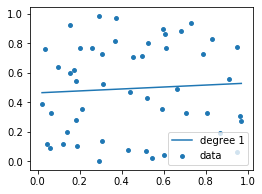

Degree 2 | MSE: 0.0881 | R^2: 0.0457


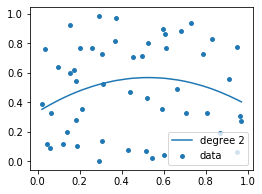

Degree 3 | MSE: 0.0879 | R^2: 0.0472


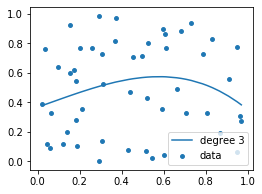

Degree 4 | MSE: 0.0864 | R^2: 0.0632


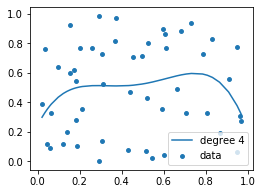

Degree 5 | MSE: 0.0858 | R^2: 0.0703


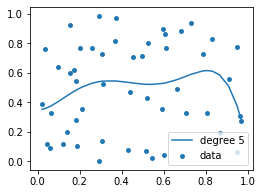

Degree 6 | MSE: 0.0834 | R^2: 0.0958


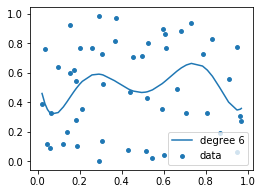

Degree 7 | MSE: 0.0834 | R^2: 0.0958


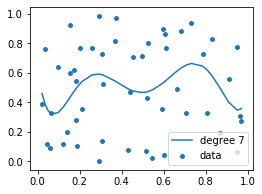

Degree 8 | MSE: 0.0833 | R^2: 0.0972


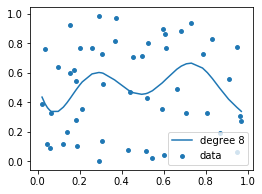

Degree 9 | MSE: 0.0811 | R^2: 0.1207


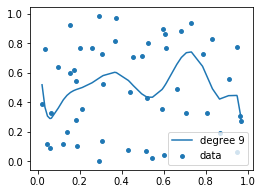

Degree 10 | MSE: 0.0811 | R^2: 0.1213


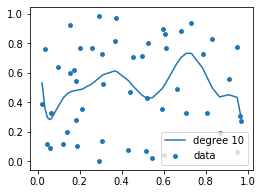

Degree 11 | MSE: 0.0810 | R^2: 0.1221


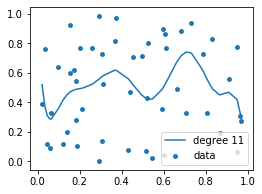

Degree 12 | MSE: 0.0801 | R^2: 0.1318


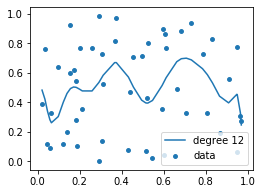

Degree 13 | MSE: 0.0799 | R^2: 0.1345


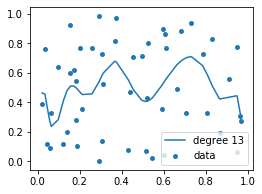

Degree 14 | MSE: 0.0798 | R^2: 0.1355


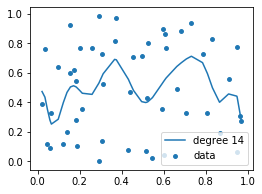

Degree 15 | MSE: 0.0792 | R^2: 0.1422


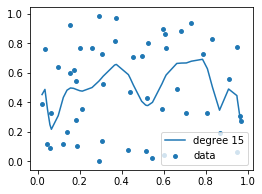

Degree 16 | MSE: 0.0786 | R^2: 0.1478


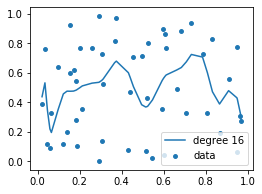

Degree 17 | MSE: 0.0775 | R^2: 0.1598


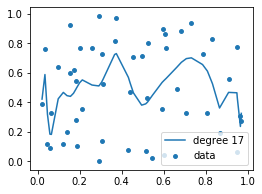

Degree 18 | MSE: 0.0757 | R^2: 0.1793


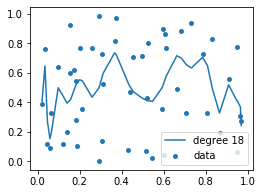

Degree 19 | MSE: 0.0761 | R^2: 0.1756


<ipython-input-3-154c67d2cf06>:19: RankWarning: Polyfit may be poorly conditioned
  y_fit, mse, r2 = evaluate_poly(d)


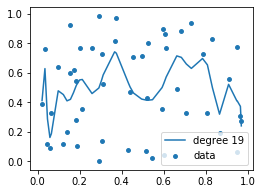

In [3]:
def evaluate_poly(deg):
    
    coeff = np.polyfit(x, y, deg)
    poly = np.poly1d(coeff)
    
    y_est = poly(x)
    
    mse = np.mean((y - y_est)**2)
    
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_est)**2)
    
    r2 = 1 - (ss_res/ss_total)
    
    return y_est, mse, r2

for d in range(1, 20):

    y_fit, mse, r2 = evaluate_poly(d)
    
    print(f"Degree {d} | MSE: {mse:.4f} | R^2: {r2:.4f}")
    
    plt.figure(figsize=(4,3))
    plt.scatter(x, y, s=15, label="data")
    plt.plot(x, y_fit, label=f"degree {d}")
    plt.legend()
    plt.show()

# Part C

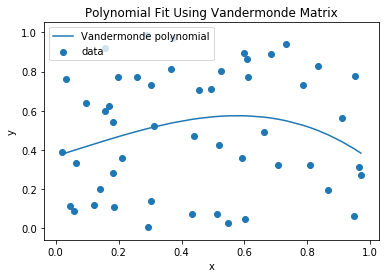

In [4]:
deg = 3

V = np.vander(x, N=deg+1, increasing=True)

VT_V = V.T @ V
VT_y = V.T @ y

coeff_vander = np.linalg.solve(VT_V, VT_y)

y_vander = V @ coeff_vander

plt.scatter(x, y, label="data")
plt.plot(x, y_vander, label="Vandermonde polynomial")
plt.title("Polynomial Fit Using Vandermonde Matrix")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [5]:
mse_vander = np.mean((y - y_vander)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_vander)**2)

r2_vander = 1 - (ss_res/ss_total)

print("\nVandermonde Fit Metrics")
print("MSE:", mse_vander)
print("R^2:", r2_vander)


Vandermonde Fit Metrics
MSE: 0.08791457423883181
R^2: 0.04718940361141288
